<a href="https://colab.research.google.com/github/marianafreitasc/CicloGuia---Seguran-a-Ciclovi-ria-do-Rio/blob/main/rede_ciclovi%C3%A1ria_(datario).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('rede_cicloviaria_datario.csv')
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,fid,ext,tipo_infra,apenas_ano,fluxo_infr,inicio,contabilizar,data_implant,vias,area_plane,local_infr,executor,final,SHAPE__Length,rp,status,cod_rp
0,1,0.998709,Faixa compartilhada na calçada,NaN,Bidirecional,Avenida Padre Guilherme Decaminada (Em frente ...,Sim,NaN,Rodovia Governador Mário Covas,5,No bordo direito da pista,NaN,Avenida Padre Guilherme Decaminada (altura da ...,998.538921,Santa Cruz,Implantada,5.3
1,2,0.333128,Faixa compartilhada na calçada,NaN,Bidirecional,Estrada Visconde de Sinimbu,Sim,NaN,Rua General Alexandre Barreto,5,No bordo direito da pista,NaN,Número 179,333.073322,Santa Cruz,Implantada,5.3
2,3,0.554299,Faixa compartilhada na calçada,NaN,Bidirecional,Em torno da Praça Guilherme da Silveira,Sim,NaN,Praça Guilherme da Silveira,5,Na calçada,NaN,Em torno da Praça Guilherme da Silveira,554.249452,Bangu,Implantada,5.1
3,4,2.042926,Faixa compartilhada na calçada,NaN,Bidirecional,Número 212,Sim,NaN,Estrada de Inhoaíba,5,No bordo esquerdo da pista,NaN,Estrada do Campinho,2042.633008,Campo Grande,Implantada,5.2
4,5,1.626672,Faixa compartilhada na calçada,NaN,Bidirecional,Estrada dos Palmares,Sim,NaN,Estrada do Cortume,5,No bordo direito da pista,NaN,Número 1462,1626.393500,Santa Cruz,Implantada,5.3


Esse dataset contém informações sobre toda a infraestrutura cicloviário do Rio. Representando informações como:


*   ext - extensão por km
*   tipo_infra - tipo da faixa para o ciclista
*   rp - bairro ou região
*   area_plane - área de planejamento(1 a 5)
*  fluxo_infr - direção do fluxo da faixa
*  local_infr - onde na via fica a infraestrutura



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fid            576 non-null    int64  
 1   ext            576 non-null    float64
 2   tipo_infra     576 non-null    object 
 3   apenas_ano     92 non-null     float64
 4   fluxo_infr     576 non-null    object 
 5   inicio         576 non-null    object 
 6   contabilizar   576 non-null    object 
 7   data_implant   92 non-null     object 
 8   vias           576 non-null    object 
 9   area_plane     576 non-null    int64  
 10  local_infr     576 non-null    object 
 11  executor       89 non-null     object 
 12  final          576 non-null    object 
 13  SHAPE__Length  575 non-null    float64
 14  rp             576 non-null    object 
 15  status         576 non-null    object 
 16  cod_rp         563 non-null    float64
dtypes: float64(4), int64(2), object(11)
memory usage: 76.6

In [ ]:
df.describe()

,fid,ext,apenas_ano,area_plane,SHAPE__Length,cod_rp
count,576.000000,576.000000,92.000000,576.000000,575.000000,563.000000
mean,291.781250,0.812567,2022.706522,3.024306,812.625402,3.246359
std,170.261561,1.337367,1.084740,1.272901,1338.421151,1.322795
min,1.000000,0.004600,2022.000000,1.000000,4.599365,1.000000
25%,144.750000,0.209001,2022.000000,2.000000,208.873989,2.100000
50%,290.500000,0.438484,2022.000000,3.000000,436.633690,3.400000
75%,434.250000,0.784289,2024.000000,4.000000,784.377402,4.200000
max,591.000000,12.236407,2025.000000,5.000000,12234.627491,5.400000


In [ ]:
df.isnull().sum()

,0
fid,0
ext,0
tipo_infra,0
apenas_ano,484
fluxo_infr,0
inicio,0
contabilizar,0
data_implant,484
vias,0
area_plane,0


As colunas 'executor', 'data_implant' e 'apenas_ano' tem mais de 84% dos dados nulo o que inviabilisa a ánalise(excluir essas colunas no tratamento já que não terão utilidade em nosso projeto)

###1 - Análise Univariada

iremos analisar uma variavel por vez afim de entender a distribuição da extensão dos trechos e a frequência de cada categoria

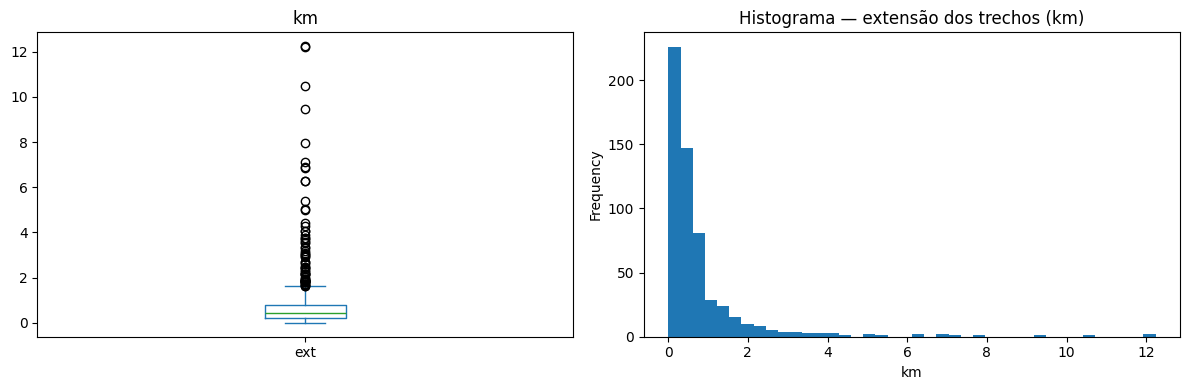

In [ ]:
#Boxplot e histograma da esxtensão em km
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['ext'].plot(kind='box', ax=axes[0])
axes[0].set_title('Boxplot - extensão por trecho em km')
axes[0].set_title('km')

df['ext'].plot(kind='hist', bins=40, ax=axes[1])
axes[1].set_title('Histograma — extensão dos trechos (km)')
axes[1].set_xlabel('km')

plt.tight_layout()
plt.show()

Tomar cuidado com a média, nesse caso a maior parte dos trechos então por volta de 1km mas alguns poucos são muito longos fazendo a média crescer e ficar irreal. Já a mediana é melhor nesse caso(linha do meio no boxplot) pois teria o valor no meio entre todos

In [ ]:
df['tipo_infra'].value_counts()

,count
tipo_infra,
Faixa compartilhada na calçada,233
Faixa compartilhada na pista,186
Ciclofaixa,98
Ciclovia,59


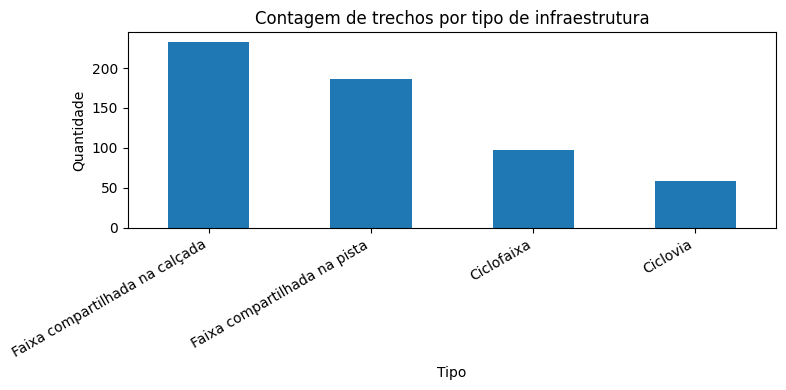

In [ ]:
df['tipo_infra'].value_counts().plot(kind='bar', figsize=(8, 4))
plt.title('Contagem de trechos por tipo de infraestrutura')
plt.xlabel('Tipo')
plt.ylabel('Quantidade')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#extensão total por tipo de faixa
df.groupby('tipo_infra')['ext'].sum().sort_values(ascending=False)

,ext
tipo_infra,
Faixa compartilhada na calçada,233.969618
Faixa compartilhada na pista,127.857495
Ciclovia,61.702326
Ciclofaixa,44.509117


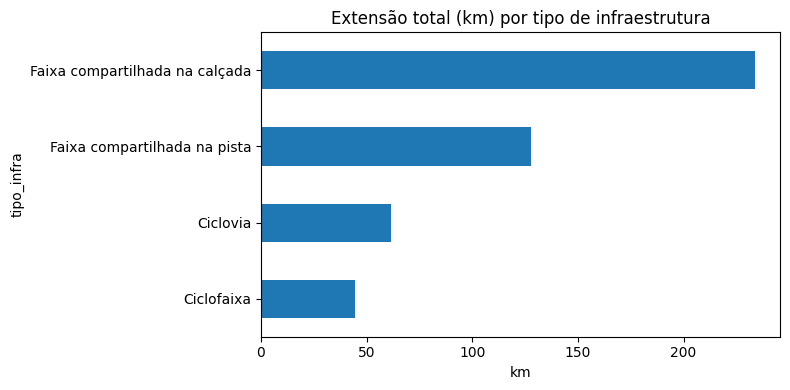

In [ ]:
df.groupby('tipo_infra')['ext'].sum().sort_values().plot(kind='barh', figsize=(8, 4))
plt.title('Extensão total (km) por tipo de infraestrutura')
plt.xlabel('km')
plt.tight_layout()
plt.show()

A faixa compartilhada é predominante tanto em extensão total quanto em quantidade, já a faixa mais segura so representa 13% do total

In [ ]:
#top 10 bairros por extensão total de ciclofaixas

top10 = df.groupby('rp')['ext'].sum().sort_values(ascending=False).head(10)
top10

,ext
rp,
Barra da Tijuca,85.271953
Tijuca,46.136041
Guaratiba,42.729720
Jacarepaguá,35.720620
Campo Grande,34.521867
Santa Cruz,30.480555
Ilha do Governador,29.623427
Centro,22.904016
Copacabana,20.026637


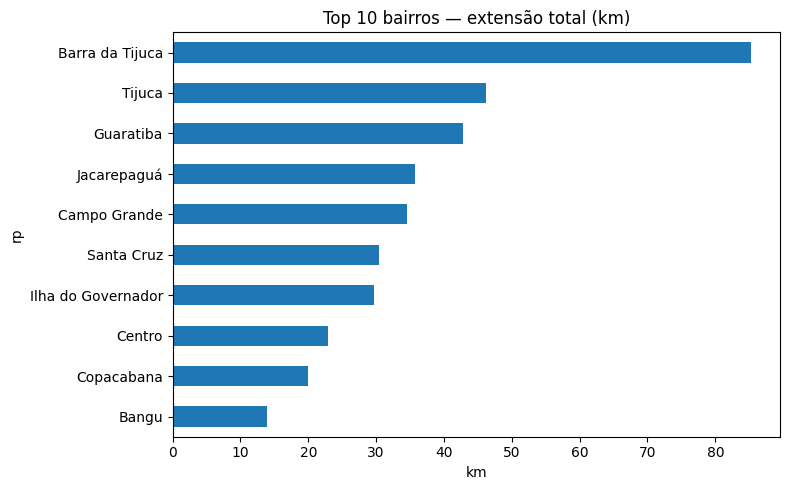

In [ ]:
top10.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Top 10 bairros — extensão total (km)')
plt.xlabel('km')
plt.tight_layout()
plt.show()

In [ ]:
#extensão por área de planejamento
df['area_plane'].value_counts().sort_index()

,count
area_plane,
1,54
2,206
3,79
4,146
5,91


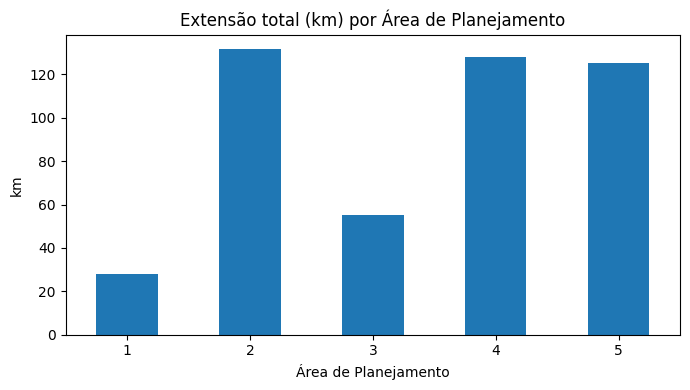

In [ ]:
df.groupby('area_plane')['ext'].sum().plot(kind='bar', figsize=(7, 4))
plt.title('Extensão total (km) por Área de Planejamento')
plt.xlabel('Área de Planejamento')
plt.ylabel('km')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#contagem por tipo de fluxo
df['fluxo_infr'].value_counts()

,count
fluxo_infr,
Bidirecional,354
"Unidirecional, no fluxo dos automóveis",169
Não identificado,34
Unidirecional,11
"Unidirecional, isolada em relação à via pública",4
"Unidirecional, no contrafluxo dos automóveis",3
"Uniderecional, no sentido do fluxo do veículo",1


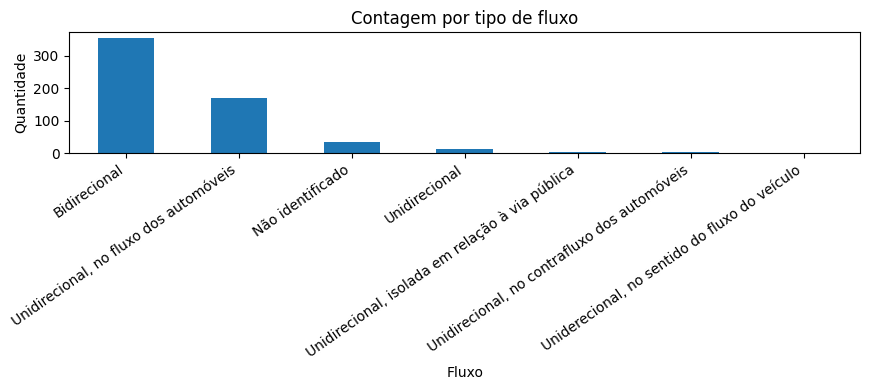

In [ ]:
df['fluxo_infr'].value_counts().plot(kind='bar', figsize=(9, 4))
plt.title('Contagem por tipo de fluxo')
plt.xlabel('Fluxo')
plt.ylabel('Quantidade')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

###2 - Analise multivariada

agora iremos analisar a relação entre duas ou mais variaveis ao mesmo tempo.

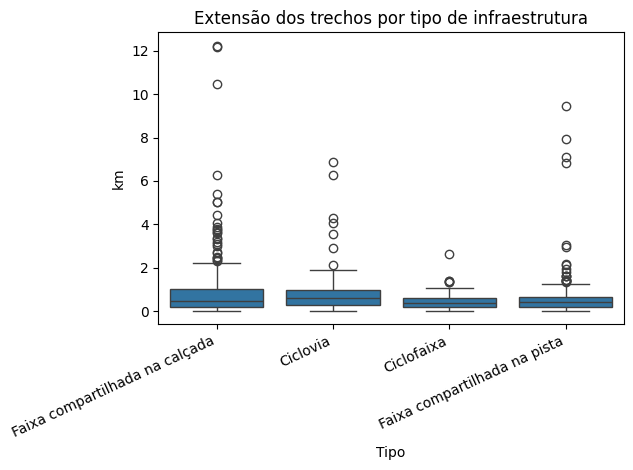

In [ ]:
#Boxplot: extensão por tipo de infraestrutura

sns.boxplot(x='tipo_infra', y='ext', data=df)
plt.title('Extensão dos trechos por tipo de infraestrutura')
plt.xlabel('Tipo')
plt.ylabel('km')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

A ciclovia segregada tende a ter trechos mais longos que as faixas compartilhadas. Trechos muito curtos aparecem como outliers em todos os tipos

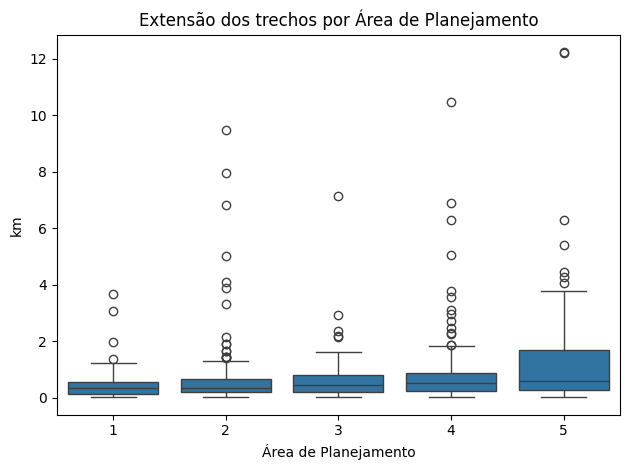

In [ ]:
# Boxplot: extensão por área de planejamento
sns.boxplot(x='area_plane', y='ext', data=df)
plt.title('Extensão dos trechos por Área de Planejamento')
plt.xlabel('Área de Planejamento')
plt.ylabel('km')
plt.tight_layout()
plt.show()

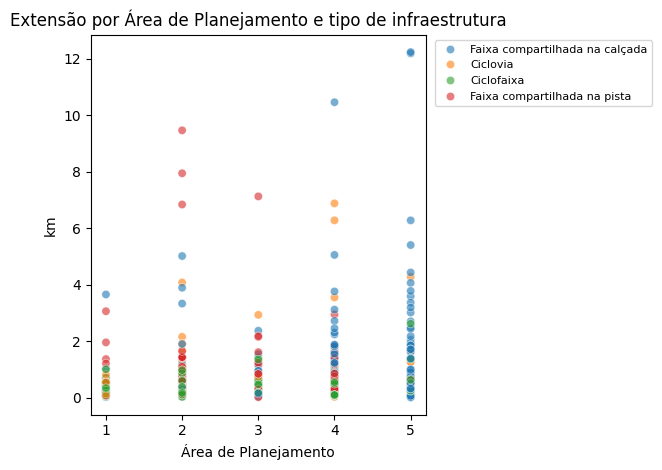

In [ ]:
# Scatterplot: quais os tipos de faixas mais recorrentes em cada área de planejamento e sua km
sns.scatterplot(x='area_plane', y='ext', hue='tipo_infra', data=df, alpha=0.6)
plt.title('Extensão por Área de Planejamento e tipo de infraestrutura')
plt.xlabel('Área de Planejamento')
plt.ylabel('km')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

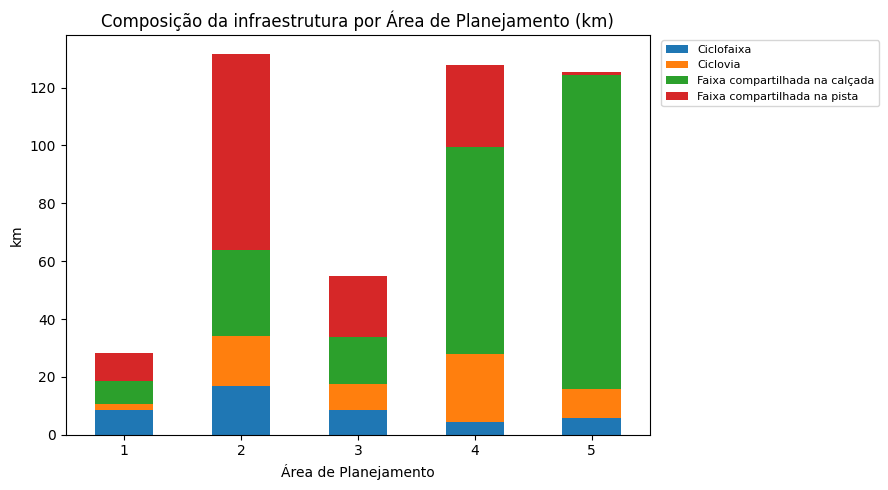

In [ ]:
# Composição por tipo dentro de cada área de planejamento
pivot = df.pivot_table(index='area_plane', columns='tipo_infra', values='ext', aggfunc='sum', fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(9, 5))
plt.title('Composição da infraestrutura por Área de Planejamento (km)')
plt.xlabel('Área de Planejamento')
plt.ylabel('km')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

A AP5(zona oeste) tem grande extensao, mas quase toda em faixa compartilhada na calçada, a infraestrutura de menor proteção. A AP4 (Barra/jacarepagua) é a que tem maior proporção de ciclovia segrgada.

###3 - Correlação e Heatmap

In [ ]:
# Selecionando apenas colunas numéricas relevantes ao projeto
df_corr = df[['ext', 'area_plane', 'SHAPE__Length', 'cod_rp']].dropna()
df_corr.corr()

,ext,area_plane,SHAPE__Length,cod_rp
ext,1.000000,0.190474,1.000000,0.195578
area_plane,0.190474,1.000000,0.190442,0.993319
SHAPE__Length,1.000000,0.190442,1.000000,0.195547
cod_rp,0.195578,0.993319,0.195547,1.000000


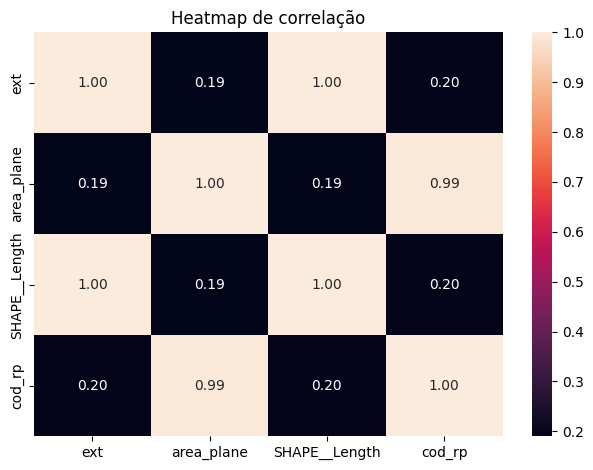

In [ ]:
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f')
plt.title('Heatmap de correlação')
plt.tight_layout()
plt.show()

ext e shape_length têm correlação de 1.0 são a mesma informação em unidades diferentes então a correlação faz sentido. cod_rp e area_plane têm correlação moderada, o que tambem faz sentido já que o código de planejamento da região está relacionado com a área

Principais conclusões da EDA


1.   Extensão total: 468 km de infraestrutura cicloviária implantada, divididos em 576 trechos.
2.   Fragmentação: a mediana dos trechos é de apenas 440m — a rede é descontínua.
3. Tipo dominante: 77% da rede é faixa compartilhada (calçada ou pista), com baixa proteção ao ciclista. Apenas 13% é ciclovia segregada.
4. Desigualdade geográfica: Barra da Tijuca concentra 85 km; o Centro tem apenas 28 km, apesar de ser o principal polo de trabalho da cidade.
5. Qualidade dos dados: as colunas de data e executor têm 84% de nulos, impedindo análise temporal. Mas para o projeto os outros dados são o suficiente
6. Próximo passo: cruzar esses dados com os acidentes de trânsito e crimes contra ciclistas do ISP para calcular o score de risco por trecho.

